# Module 1 — From Linear Models to Deep Learning
## End-to-End Machine Learning Demo with PyTorch
**Applied AI Mastery Program** | Rina Buoy, PhD

---

| Section | Topic |
|---------|-------|
| §1 | Math Foundations — `Y = WXᵀ + w₀` (PyTorch tensors) |
| §2 | Input Encoding — categorical (one-hot, ordinal, binary) + numeric (StandardScaler, MinMaxScaler) |
| §3A–D | Regression — `nn.Linear` with no / L2 / L1 / L1+L2 regularization |
| §3E | Hyperparameter Tuning — manual K-Fold CV loop |
| §3F | Regression Evaluation — MSE, MAE, R² |
| §4A–B | Binary Classification — `nn.Linear` + `BCEWithLogitsLoss` |
| §4C–F | Classification Evaluation — Confusion Matrix, Precision, Recall, F1, ROC-AUC |
| §5 | Multiclass — `nn.Linear` + `CrossEntropyLoss` (Softmax) |

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.datasets import fetch_california_housing, load_breast_cancer, load_iris
from sklearn.model_selection import train_test_split, KFold, StratifiedKFold
from sklearn.preprocessing import (
    StandardScaler, MinMaxScaler, OneHotEncoder, OrdinalEncoder
)
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc, roc_auc_score, classification_report
)
import warnings
warnings.filterwarnings('ignore')

torch.manual_seed(42)
np.random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
sns.set_theme(style='whitegrid', palette='muted')
print(f'✓ Libraries imported  |  PyTorch {torch.__version__}  |  device: {device}')

✓ Libraries imported  |  PyTorch 2.5.1  |  device: cpu


---
## §1  Math Foundations — `Y = WXᵀ + w₀`
> **Slides 4–14** — A linear model is a matrix multiplication between weight matrix **W** and transposed feature matrix **Xᵀ**, plus a bias **w₀**.
>
> - **Linear Regression**: activation = identity `f(x) = x` (slide 24)
> - **Logistic Regression**: activation = sigmoid `g(z) = 1/(1+e⁻ᶻ)` (slide 28)
> - **Softmax Classifier**: activation = softmax (slide 29–31)


X  shape: (4, 3)  (n_samples × m_features)
W  shape: (2, 3)  (k_outputs × m_features)
w0 shape: (2,) (k_outputs,)
Y  shape: (4, 2)  (n_samples × k_outputs)

Y (4 samples, 2 outputs):
tensor([[12.4000, 25.6000],
        [13.0000, 26.5000],
        [11.7000, 24.8000],
        [13.3000, 26.7000]])

Verify Y[0,0]: [0.5, 0.20000000298023224, 0.10000000149011612] · [2.0, 4.0, 6.0] + 10.0 = 12.399999618530273  ✓


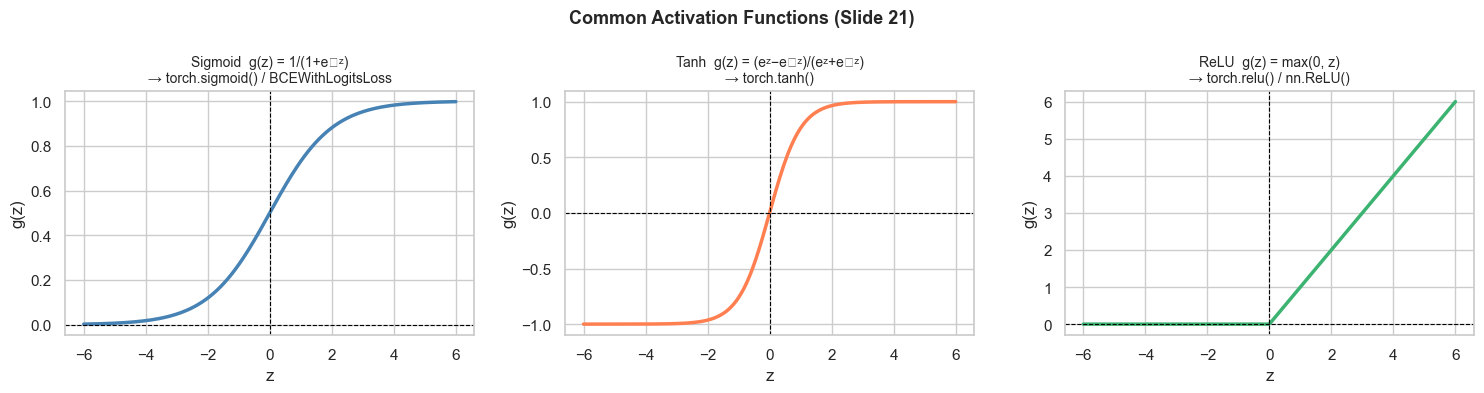

In [2]:
# ── Slide 12 example — using PyTorch tensors ──────────────────────────────────
# X: (4 samples, 3 features)   W: (2 outputs, 3 features)   w0: (2 outputs,)

X = torch.tensor([[2., 4., 6.],
                   [5., 1., 3.],
                   [1., 2., 8.],
                   [3., 7., 4.]])      # shape (4, 3)

W  = torch.tensor([[0.5, 0.2, 0.1],
                    [1.0, 0.3, 0.4]])  # shape (2, 3)
w0 = torch.tensor([10., 20.])          # shape (2,)

# Y = W @ X.T + w0  → broadcast w0 along n dimension
Y = (W @ X.T).T + w0                   # shape (4, 2)

print(f'X  shape: {tuple(X.shape)}  (n_samples × m_features)')
print(f'W  shape: {tuple(W.shape)}  (k_outputs × m_features)')
print(f'w0 shape: {tuple(w0.shape)} (k_outputs,)')
print(f'Y  shape: {tuple(Y.shape)}  (n_samples × k_outputs)')
print(f'\nY (4 samples, 2 outputs):\n{Y}')

# Manual verification sample 1, output 1
check = (W[0] * X[0]).sum() + w0[0]
print(f'\nVerify Y[0,0]: {W[0].tolist()} · {X[0].tolist()} + {w0[0].item()} = {check.item()}  ✓')

# ── Sigmoid / Tanh / ReLU (torch built-ins) ────────────────────────────────────
z      = torch.linspace(-6, 6, 200)
sigmoid = torch.sigmoid(z).numpy()
relu    = torch.relu(z).numpy()
tanh_z  = torch.tanh(z).numpy()
z_np    = z.numpy()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, y_vals, name, color in [
    (axes[0], sigmoid, 'Sigmoid  g(z) = 1/(1+e⁻ᶻ)\n→ torch.sigmoid() / BCEWithLogitsLoss', 'steelblue'),
    (axes[1], tanh_z,  'Tanh  g(z) = (eᶻ−e⁻ᶻ)/(eᶻ+e⁻ᶻ)\n→ torch.tanh()', 'coral'),
    (axes[2], relu,    'ReLU  g(z) = max(0, z)\n→ torch.relu() / nn.ReLU()', 'mediumseagreen'),
]:
    ax.plot(z_np, y_vals, color=color, lw=2.5)
    ax.axhline(0, color='black', lw=0.8, linestyle='--')
    ax.axvline(0, color='black', lw=0.8, linestyle='--')
    ax.set_title(name, fontsize=10)
    ax.set_xlabel('z')
    ax.set_ylabel('g(z)')

plt.suptitle('Common Activation Functions (Slide 21)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## §2  Pre-Processing
> **Slides 34–37** — Before feeding data into any linear model, we must convert all inputs to numbers.
>
> | Input type | Encoding method | sklearn class |
> |------------|-----------------|---------------|
> | Nominal (no order) | One-hot / Dummy | `OneHotEncoder` |
> | Ordinal (has order) | Integer map | `OrdinalEncoder` |
> | Binary | 0/1 | manual or `LabelEncoder` |
> | Numeric | StandardScaler (z-score) | `StandardScaler` |
> | Numeric | Min-Max | `MinMaxScaler` |


In [3]:
# ── §2.1  Categorical Encoding (Slide 35) ─────────────────────────────────────

demo = pd.DataFrame({
    'color':    ['Red', 'Green', 'Blue', 'Red', 'Green', 'Blue'],
    'quality':  ['Poor', 'Good', 'Excellent', 'Very Good', 'Good', 'Poor'],
    'has_pool': ['Yes', 'No', 'Yes', 'No', 'Yes', 'No'],
})
print('Original:')
print(demo, '\n')

# 1. One-Hot Encoding  (nominal — no natural order)
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
color_ohe = pd.DataFrame(
    ohe.fit_transform(demo[['color']]),
    columns=ohe.get_feature_names_out(['color'])
)
print('1. One-Hot Encoding (color — nominal):')
print(color_ohe, '\n')

# 2. Dummy Encoding  (drop first category to avoid multicollinearity)
ohe_d = OneHotEncoder(sparse_output=False, drop='first')
color_dummy = pd.DataFrame(
    ohe_d.fit_transform(demo[['color']]),
    columns=ohe_d.get_feature_names_out(['color'])
)
print('2. Dummy Encoding (drop="first" removes one column):')
print(color_dummy, '\n')

# 3. Ordinal Encoding  (ordinal — Poor < Good < Very Good < Excellent)
oe = OrdinalEncoder(categories=[['Poor', 'Good', 'Very Good', 'Excellent']])
quality_oe = oe.fit_transform(demo[['quality']])
print('3. Ordinal Encoding (quality — ordered):')
print(pd.DataFrame({'quality': demo['quality'], 'encoded': quality_oe.flatten()}), '\n')

# 4. Binary Encoding
demo['has_pool_binary'] = (demo['has_pool'] == 'Yes').astype(int)
print('4. Binary Encoding (has_pool):')
print(demo[['has_pool', 'has_pool_binary']])


Original:
   color    quality has_pool
0    Red       Poor      Yes
1  Green       Good       No
2   Blue  Excellent      Yes
3    Red  Very Good       No
4  Green       Good      Yes
5   Blue       Poor       No 

1. One-Hot Encoding (color — nominal):
   color_Blue  color_Green  color_Red
0         0.0          0.0        1.0
1         0.0          1.0        0.0
2         1.0          0.0        0.0
3         0.0          0.0        1.0
4         0.0          1.0        0.0
5         1.0          0.0        0.0 

2. Dummy Encoding (drop="first" removes one column):
   color_Green  color_Red
0          0.0        1.0
1          1.0        0.0
2          0.0        0.0
3          0.0        1.0
4          1.0        0.0
5          0.0        0.0 

3. Ordinal Encoding (quality — ordered):
     quality  encoded
0       Poor      0.0
1       Good      1.0
2  Excellent      3.0
3  Very Good      2.0
4       Good      1.0
5       Poor      0.0 

4. Binary Encoding (has_pool):
  has_pool  h

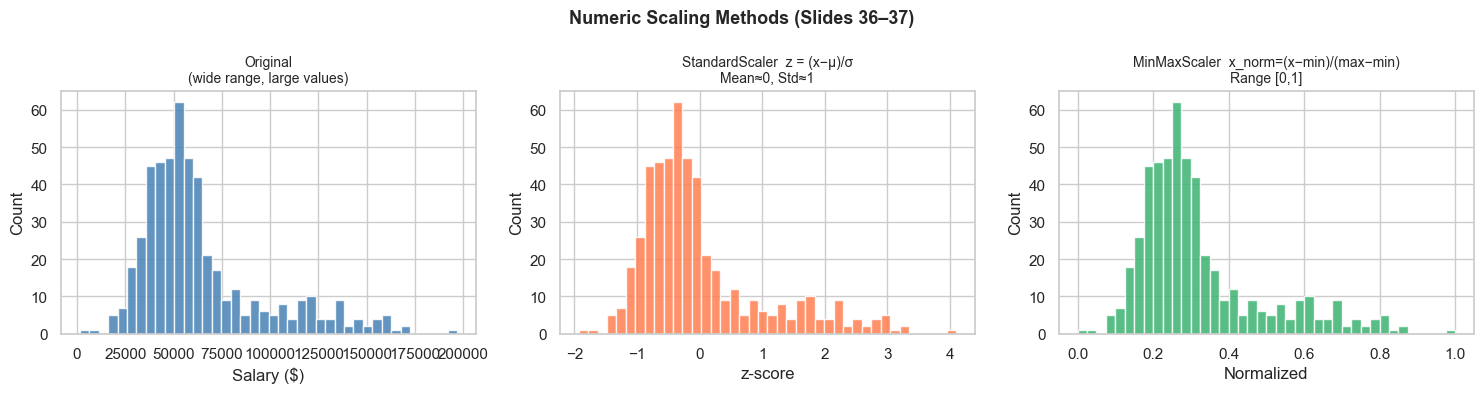

StandardScaler → mean: -0.00000, std: 1.0000
MinMaxScaler   → min:  0.0000, max: 1.0000


In [4]:
# ── §2.2  Numeric Scaling (Slides 36–37) ──────────────────────────────────────

np.random.seed(42)
salaries = np.concatenate([
    np.random.normal(50_000, 15_000, 400),
    np.random.normal(120_000, 25_000, 100)
]).clip(0).reshape(-1, 1)

std_scaler = StandardScaler()   # z = (x - μ) / σ
mm_scaler  = MinMaxScaler()     # x_norm = (x - x_min) / (x_max - x_min)

sal_std = std_scaler.fit_transform(salaries)
sal_mm  = mm_scaler.fit_transform(salaries)

configs = [
    (salaries.flatten(), 'Original\n(wide range, large values)', 'Salary ($)', 'steelblue'),
    (sal_std.flatten(),  'StandardScaler  z = (x−μ)/σ\nMean≈0, Std≈1',  'z-score',   'coral'),
    (sal_mm.flatten(),   'MinMaxScaler  x_norm=(x−min)/(max−min)\nRange [0,1]', 'Normalized', 'mediumseagreen'),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (data, title, xlabel, color) in zip(axes, configs):
    ax.hist(data, bins=40, color=color, edgecolor='white', alpha=0.85)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Count')

plt.suptitle('Numeric Scaling Methods (Slides 36–37)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'StandardScaler → mean: {sal_std.mean():.5f}, std: {sal_std.std():.4f}')
print(f'MinMaxScaler   → min:  {sal_mm.min():.4f}, max: {sal_mm.max():.4f}')


---
## §3  Regression — California Housing Dataset
> Predicting **median house value** ($100K) from 8 numeric + 2 synthetic categorical features.
>
> All models use `nn.Linear(n_in, 1)` with **MSELoss** — regularization is added via the optimizer or loss term.
>
> | Model | Regularization | PyTorch implementation |
> |-------|---------------|------------------------|
> | Linear Regression | None | `optim.Adam(params, lr=3e-3)` |
> | Ridge | L2: λΣwᵢ² | `optim.Adam(params, weight_decay=λ)` |
> | Lasso | L1: λΣ\|wᵢ\| | Manual `loss += λ · Σ\|w\|` added to MSELoss |
> | ElasticNet | L1 + L2 | `weight_decay` (L2) + manual L1 penalty |

In [5]:
# ── Load + enrich dataset ──────────────────────────────────────────────────────
housing = fetch_california_housing(as_frame=True)
df_reg  = housing.frame.copy()

np.random.seed(42)
n = len(df_reg)

df_reg['neighborhood_quality'] = np.random.choice(
    ['budget', 'standard', 'premium'], size=n, p=[0.30, 0.50, 0.20]
)
df_reg['property_type'] = np.random.choice(
    ['apartment', 'house', 'condo'], size=n, p=[0.40, 0.40, 0.20]
)
# add small signal so categoricals correlate with target
bonus = {'budget': -0.15, 'standard': 0.0, 'premium': 0.28}
df_reg['MedHouseVal'] = (df_reg['MedHouseVal'] +
                          df_reg['neighborhood_quality'].map(bonus)).clip(lower=0.5)

print(f'Shape: {df_reg.shape}')
print(f'\nData types:\n{df_reg.dtypes}')
print(f'\nTarget stats:')
print(df_reg['MedHouseVal'].describe().round(3))


Shape: (20640, 11)

Data types:
MedInc                  float64
HouseAge                float64
AveRooms                float64
AveBedrms               float64
Population              float64
AveOccup                float64
Latitude                float64
Longitude               float64
MedHouseVal             float64
neighborhood_quality     object
property_type            object
dtype: object

Target stats:
count    20640.000
mean         2.082
std          1.163
min          0.500
25%          1.211
50%          1.813
75%          2.662
max          5.280
Name: MedHouseVal, dtype: float64


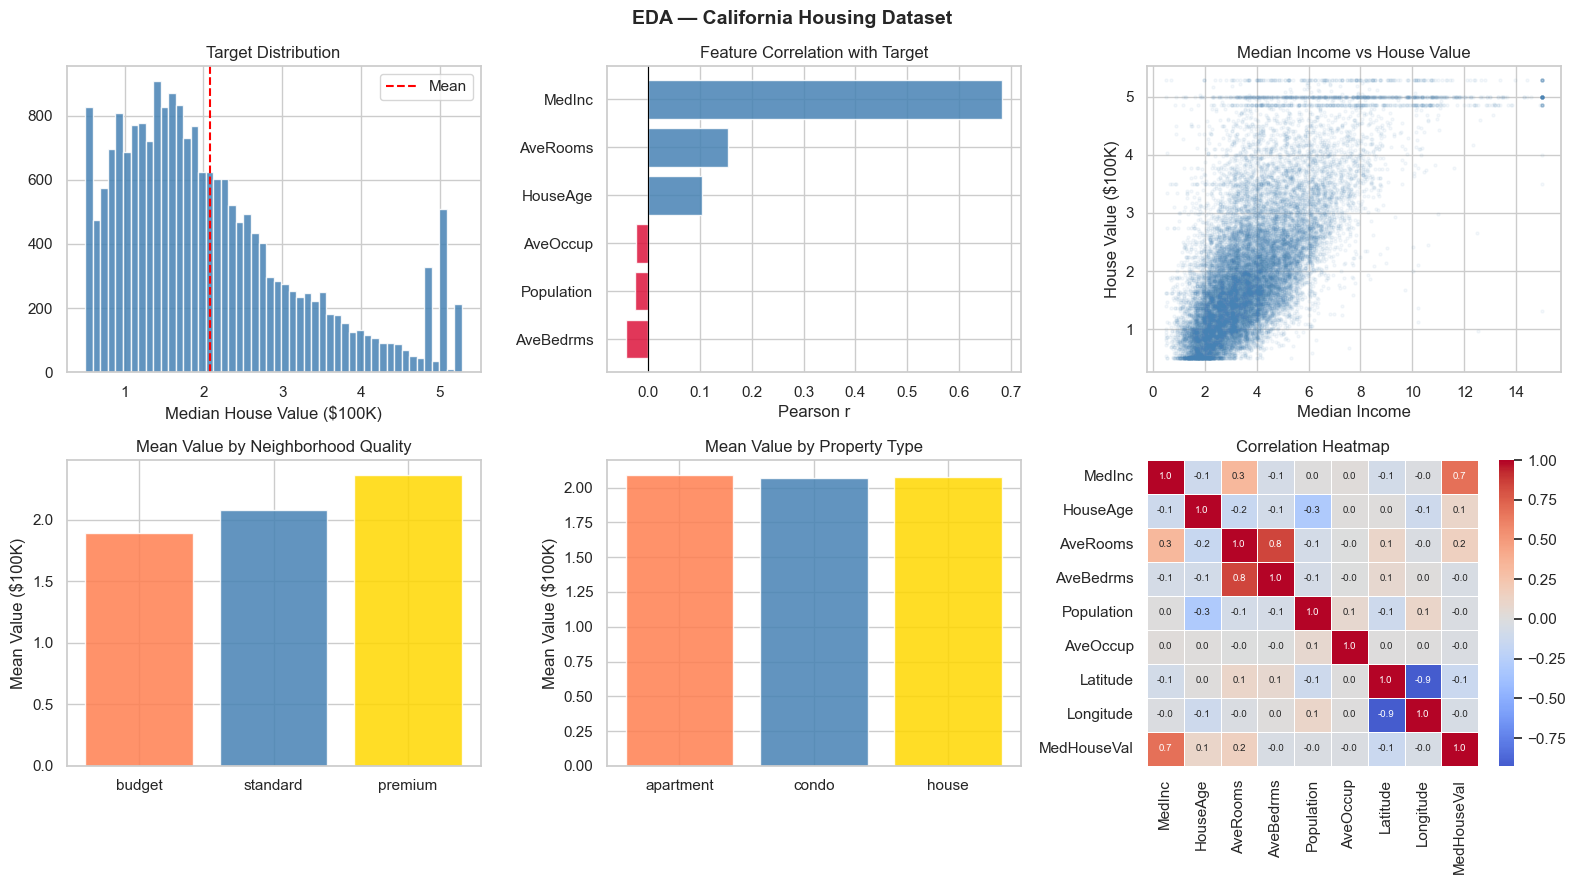

In [6]:
# ── EDA ───────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

# Target distribution
axes[0,0].hist(df_reg['MedHouseVal'], bins=50, color='steelblue',
               edgecolor='white', alpha=0.85)
axes[0,0].axvline(df_reg['MedHouseVal'].mean(), color='red', ls='--', label='Mean')
axes[0,0].set_title('Target Distribution')
axes[0,0].set_xlabel('Median House Value ($100K)')
axes[0,0].legend()

# Correlation bar
num_feats = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup']
corrs = df_reg[num_feats + ['MedHouseVal']].corr()['MedHouseVal'][:-1].sort_values()
bar_colors = ['crimson' if c < 0 else 'steelblue' for c in corrs]
axes[0,1].barh(corrs.index, corrs.values, color=bar_colors, edgecolor='white', alpha=0.85)
axes[0,1].axvline(0, color='black', lw=0.8)
axes[0,1].set_title('Feature Correlation with Target')
axes[0,1].set_xlabel('Pearson r')

# Scatter: MedInc vs target
axes[0,2].scatter(df_reg['MedInc'], df_reg['MedHouseVal'],
                  alpha=0.05, color='steelblue', s=5)
axes[0,2].set_title('Median Income vs House Value')
axes[0,2].set_xlabel('Median Income')
axes[0,2].set_ylabel('House Value ($100K)')

# Categorical: neighborhood quality
nq = df_reg.groupby('neighborhood_quality')['MedHouseVal'].mean() \
           .reindex(['budget', 'standard', 'premium'])
axes[1,0].bar(nq.index, nq.values, color=['coral','steelblue','gold'],
              edgecolor='white', alpha=0.85)
axes[1,0].set_title('Mean Value by Neighborhood Quality')
axes[1,0].set_ylabel('Mean Value ($100K)')

# Categorical: property type
pt = df_reg.groupby('property_type')['MedHouseVal'].mean()
axes[1,1].bar(pt.index, pt.values, color=['coral','steelblue','gold'],
              edgecolor='white', alpha=0.85)
axes[1,1].set_title('Mean Value by Property Type')
axes[1,1].set_ylabel('Mean Value ($100K)')

# Heatmap
num_cols = df_reg.select_dtypes(include=[np.number]).columns
sns.heatmap(df_reg[num_cols].corr(), annot=True, fmt='.1f',
            cmap='coolwarm', center=0, ax=axes[1,2],
            annot_kws={'size': 7}, linewidths=0.4)
axes[1,2].set_title('Correlation Heatmap')

plt.suptitle('EDA — California Housing Dataset', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


In [ ]:
# ── Feature definitions + preprocessing ───────────────────────────────────────
numeric_feats  = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms',
                  'Population', 'AveOccup', 'Latitude', 'Longitude']
nominal_feats  = ['neighborhood_quality', 'property_type']

X_reg = df_reg[numeric_feats + nominal_feats]
y_reg = df_reg['MedHouseVal']

X_tr_r, X_te_r, y_tr_r, y_te_r = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)
print(f'Train: {X_tr_r.shape}  |  Test: {X_te_r.shape}')

preprocessor_r = ColumnTransformer(transformers=[
    ('num', StandardScaler(),                                          numeric_feats),
    ('nom', OneHotEncoder(drop='first', handle_unknown='ignore'),      nominal_feats),
], remainder='drop')

# Fit on train, transform both splits → PyTorch float32 tensors
X_tr_np = preprocessor_r.fit_transform(X_tr_r)
X_te_np = preprocessor_r.transform(X_te_r)

X_tr_t = torch.tensor(X_tr_np, dtype=torch.float32)
X_te_t = torch.tensor(X_te_np, dtype=torch.float32)
y_tr_t = torch.tensor(y_tr_r.values, dtype=torch.float32)
y_te_t = torch.tensor(y_te_r.values, dtype=torch.float32)
n_features = X_tr_t.shape[1]

print(f'Tensor shapes — X_tr: {tuple(X_tr_t.shape)}, y_tr: {tuple(y_tr_t.shape)}')
print(f'n_features after encoding: {n_features}')

# ── PyTorch utilities (shared by §3A–3E) ─────────────────────────────────────

class LinearModel(nn.Module):
    """Single nn.Linear layer — covers LinearReg / Ridge / Lasso / ElasticNet."""
    def __init__(self, n_in):
        super().__init__()
        self.linear = nn.Linear(n_in, 1)

    def forward(self, x):
        # x -> (bs, n_in)  |  self.linear(x) -> (bs, 1)
        return self.linear(x).squeeze(-1) # (bs,1) -> (bs)


def train_reg(model, X, y, optimizer, n_epochs=500, l1_lam=0.0):
    """Full-batch gradient descent for regression. Returns per-epoch MSE list."""
    criterion = nn.MSELoss()
    model.train()
    losses = []
    for _ in range(n_epochs):
        optimizer.zero_grad() # reset gradients
        loss = criterion(model(X), y) # loss calculation
        if l1_lam > 0: # apply l1 regularization if lambda > 0
            l1 = sum(p.abs().sum() for p in model.parameters())
            loss = loss + l1_lam * l1
        loss.backward() # compute gradients
        optimizer.step() # update parameters
        losses.append(loss.item())
    return losses


@torch.no_grad()
def eval_reg(model, X_tr, y_tr, X_te, y_te, name):
    model.eval()
    pred_tr = model(X_tr).numpy()
    pred_te = model(X_te).numpy()
    return {
        'Model':     name,
        'Train R²':  r2_score(y_tr.numpy(), pred_tr),
        'Test R²':   r2_score(y_te.numpy(), pred_te),
        'Train MSE': mean_squared_error(y_tr.numpy(), pred_tr),
        'Test MSE':  mean_squared_error(y_te.numpy(), pred_te),
        'Train MAE': mean_absolute_error(y_tr.numpy(), pred_tr),
        'Test MAE':  mean_absolute_error(y_te.numpy(), pred_te),
    }

reg_results = []
print('\n✓ LinearModel, train_reg(), eval_reg() defined')

Train: (16512, 10)  |  Test: (4128, 10)
Tensor shapes — X_tr: (16512, 12), y_tr: (16512,)
n_features after encoding: 12

✓ LinearModel, train_reg(), eval_reg() defined


§3A  Linear Regression (PyTorch)
  Train R²=0.4784  Test R²=0.4583
  Train MSE=0.7078  Test MSE=0.7226


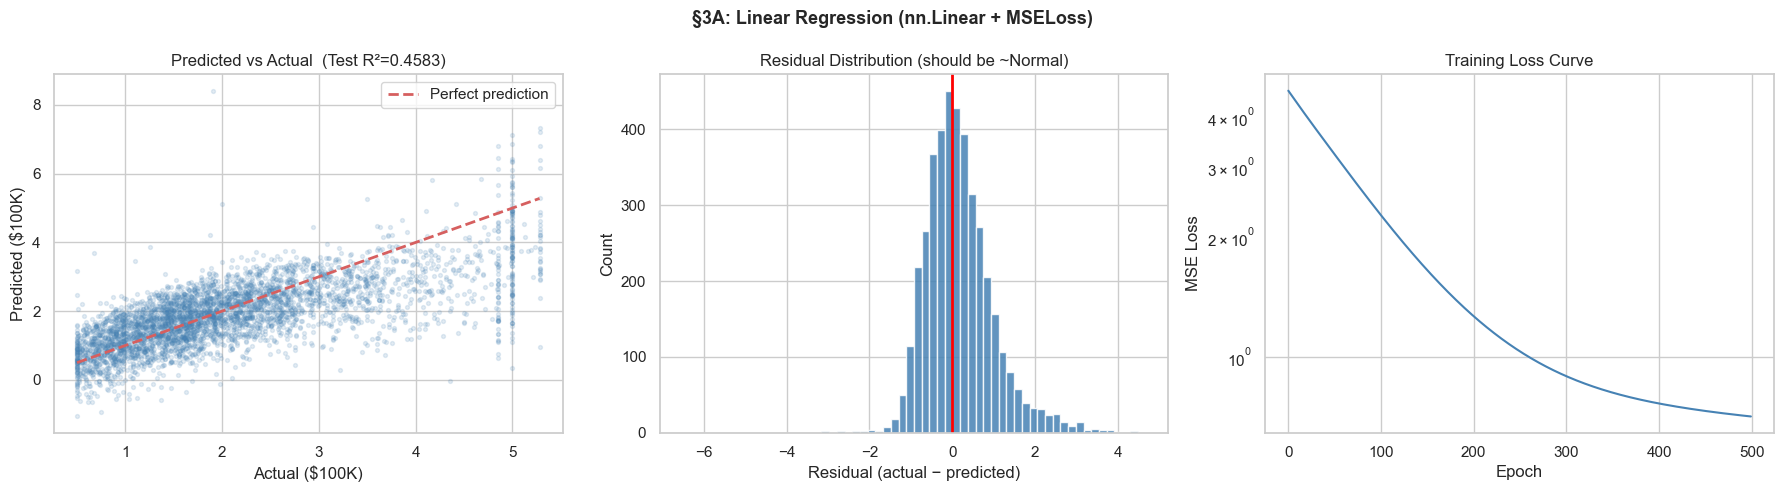

In [8]:
# ── §3A  Linear Regression — nn.Linear + MSELoss, no regularization ───────────
# Equivalent to: minimize (1/n)Σ(yᵢ − ŷᵢ)²  with  ŷ = w·x + b

torch.manual_seed(42)
model_lr = LinearModel(n_features)
opt_lr   = optim.Adam(model_lr.parameters(), lr=3e-3)
hist_lr  = train_reg(model_lr, X_tr_t, y_tr_t, opt_lr, n_epochs=500)
m_lr = eval_reg(model_lr, X_tr_t, y_tr_t, X_te_t, y_te_t, 'LinearReg (no reg)')
reg_results.append(m_lr)

print('§3A  Linear Regression (PyTorch)')
print(f"  Train R²={m_lr['Train R²']:.4f}  Test R²={m_lr['Test R²']:.4f}")
print(f"  Train MSE={m_lr['Train MSE']:.4f}  Test MSE={m_lr['Test MSE']:.4f}")

y_pred_lr = model_lr(X_te_t).detach().numpy()
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

lim = [y_te_r.min(), y_te_r.max()]
axes[0].scatter(y_te_r, y_pred_lr, alpha=0.15, color='steelblue', s=8)
axes[0].plot(lim, lim, 'r--', lw=2, label='Perfect prediction')
axes[0].set_xlabel('Actual ($100K)')
axes[0].set_ylabel('Predicted ($100K)')
axes[0].set_title(f'Predicted vs Actual  (Test R²={m_lr["Test R²"]:.4f})')
axes[0].legend()

residuals = y_te_r.values - y_pred_lr
axes[1].hist(residuals, bins=60, color='steelblue', edgecolor='white', alpha=0.85)
axes[1].axvline(0, color='red', lw=2)
axes[1].set_xlabel('Residual (actual − predicted)')
axes[1].set_ylabel('Count')
axes[1].set_title('Residual Distribution (should be ~Normal)')

axes[2].plot(hist_lr, color='steelblue', lw=1.5)
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('MSE Loss')
axes[2].set_title('Training Loss Curve')
axes[2].set_yscale('log')

plt.suptitle('§3A: Linear Regression (nn.Linear + MSELoss)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [9]:
# ── §3B  Ridge Regression — L2 via optimizer weight_decay ─────────────────────
# Effective loss: MSE + weight_decay · Σwᵢ²
# Adam's weight_decay parameter adds L2 shrinkage to every parameter update.
# Coefficients shrink toward zero but are never exactly zero.

torch.manual_seed(42)
model_ridge = LinearModel(n_features)
opt_ridge   = optim.Adam(model_ridge.parameters(), lr=3e-3, weight_decay=1.0)
hist_ridge  = train_reg(model_ridge, X_tr_t, y_tr_t, opt_ridge, n_epochs=500)
m_ridge = eval_reg(model_ridge, X_tr_t, y_tr_t, X_te_t, y_te_t, 'Ridge (wd=1.0)')
reg_results.append(m_ridge)

print('§3B  Ridge Regression — L2 (weight_decay=1.0)')
print(f"  Train R²={m_ridge['Train R²']:.4f}  Test R²={m_ridge['Test R²']:.4f}")
print(f"  Train MSE={m_ridge['Train MSE']:.4f}  Test MSE={m_ridge['Test MSE']:.4f}")
print('  → weight_decay shrinks all weights; none are exactly zeroed out')

§3B  Ridge Regression — L2 (weight_decay=1.0)
  Train R²=0.1702  Test R²=0.1658
  Train MSE=1.1262  Test MSE=1.1126
  → weight_decay shrinks all weights; none are exactly zeroed out


In [10]:
# ── §3C  Lasso — L1 via manual penalty term ───────────────────────────────────
# Effective loss: MSE + l1_lam · Σ|wᵢ|
# The L1 penalty pushes weights toward (but not exactly to) zero with gradient descent.
# True exact sparsity requires coordinate descent (as in sklearn); GD gives near-sparsity.

torch.manual_seed(42)
model_lasso = LinearModel(n_features)
opt_lasso   = optim.Adam(model_lasso.parameters(), lr=3e-3)
hist_lasso  = train_reg(model_lasso, X_tr_t, y_tr_t, opt_lasso, n_epochs=500, l1_lam=0.01)
m_lasso = eval_reg(model_lasso, X_tr_t, y_tr_t, X_te_t, y_te_t, 'Lasso (λ=0.01)')
reg_results.append(m_lasso)

coefs  = model_lasso.linear.weight.data.abs().numpy().flatten()
n_small = int(np.sum(coefs < 1e-2))

print('§3C  Lasso Regression — L1 (l1_lam=0.01)')
print(f"  Train R²={m_lasso['Train R²']:.4f}  Test R²={m_lasso['Test R²']:.4f}")
print(f"  Near-zero coefficients (|w|<0.01): {n_small}/{len(coefs)}  ← near feature selection")
print('  Note: gradient descent gives near-zero, not exact-zero (unlike sklearn coord. descent)')

§3C  Lasso Regression — L1 (l1_lam=0.01)
  Train R²=0.4759  Test R²=0.4585
  Near-zero coefficients (|w|<0.01): 1/12  ← near feature selection
  Note: gradient descent gives near-zero, not exact-zero (unlike sklearn coord. descent)


In [11]:
# ── §3D  ElasticNet — L1 + L2 Regularization ─────────────────────────────────
# Effective loss: MSE + weight_decay·Σwᵢ² + l1_lam·Σ|wᵢ|
# weight_decay handles L2 (built into Adam), l1_lam handles L1 (manual penalty)

torch.manual_seed(42)
model_enet = LinearModel(n_features)
opt_enet   = optim.Adam(model_enet.parameters(), lr=3e-3, weight_decay=0.005)
hist_enet  = train_reg(model_enet, X_tr_t, y_tr_t, opt_enet, n_epochs=500, l1_lam=0.005)
m_enet = eval_reg(model_enet, X_tr_t, y_tr_t, X_te_t, y_te_t, 'ElasticNet (L1+L2)')
reg_results.append(m_enet)

print('§3D  ElasticNet (L1 + L2)')
print(f"  Train R²={m_enet['Train R²']:.4f}  Test R²={m_enet['Test R²']:.4f}")
print('  weight_decay=0.005 (L2) + l1_lam=0.005 (L1) → equal mix')

§3D  ElasticNet (L1 + L2)
  Train R²=0.4770  Test R²=0.4585
  weight_decay=0.005 (L2) + l1_lam=0.005 (L1) → equal mix


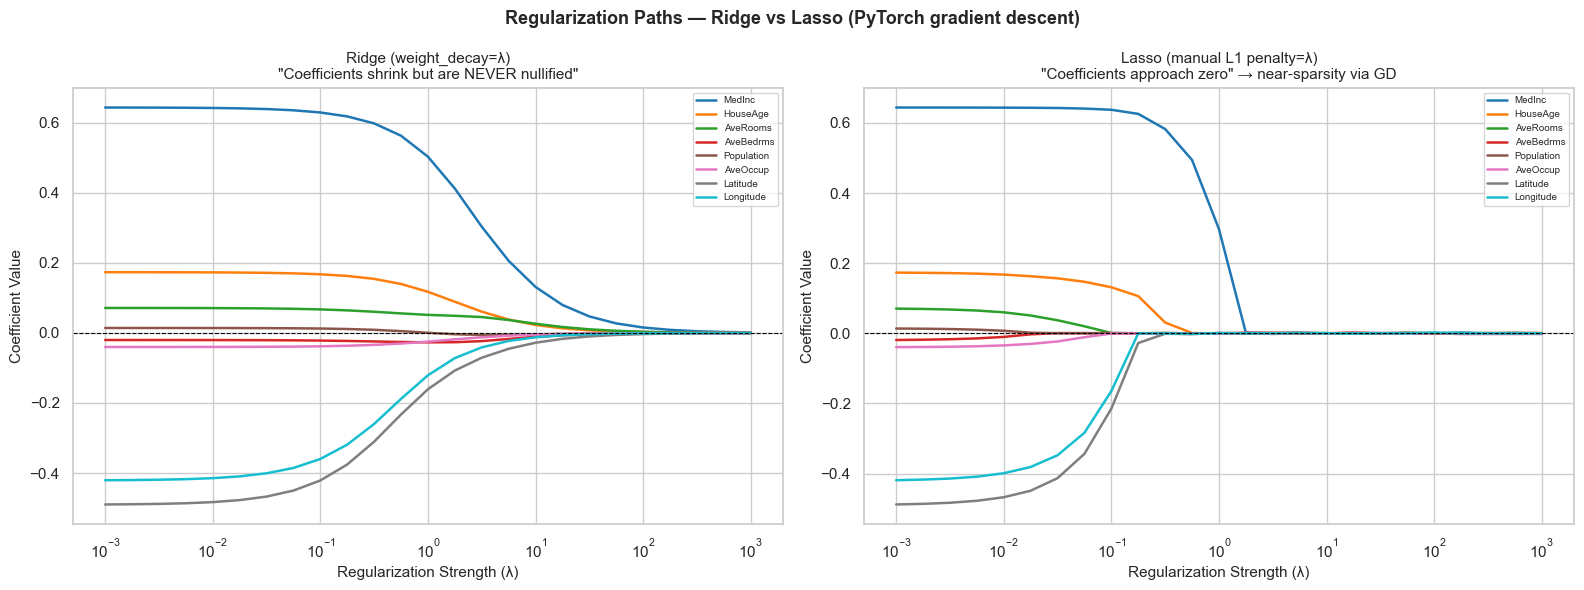

In [12]:
# ── Regularization Paths: Ridge vs Lasso (Slide 61) ──────────────────────────
# Shows coefficient magnitude as regularization strength λ increases.
# Uses numeric features only (8 features) for clarity.
# Note: Lasso path via GD shows near-zero shrinkage, not exact zeros (unlike sklearn).

X_num_np = preprocessor_r.named_transformers_['num'].transform(X_tr_r[numeric_feats])
X_num_t  = torch.tensor(X_num_np, dtype=torch.float32)
n_num    = X_num_t.shape[1]

lambdas = np.logspace(-3, 3, 25)
ridge_coefs, lasso_coefs = [], []

for lam in lambdas:
    # Ridge: weight_decay = λ
    torch.manual_seed(0)
    m = LinearModel(n_num)
    opt = optim.Adam(m.parameters(), lr=5e-3, weight_decay=float(lam))
    train_reg(m, X_num_t, y_tr_t, opt, n_epochs=200)
    ridge_coefs.append(m.linear.weight.data.numpy().flatten())

    # Lasso: manual L1 penalty = λ
    torch.manual_seed(0)
    m = LinearModel(n_num)
    opt = optim.Adam(m.parameters(), lr=5e-3)
    train_reg(m, X_num_t, y_tr_t, opt, n_epochs=200, l1_lam=float(lam))
    lasso_coefs.append(m.linear.weight.data.numpy().flatten())

ridge_coefs = np.array(ridge_coefs)
lasso_coefs = np.array(lasso_coefs)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
palette = plt.cm.tab10(np.linspace(0, 0.9, n_num))

for i, (feat, c) in enumerate(zip(numeric_feats, palette)):
    ax1.plot(lambdas, ridge_coefs[:, i], color=c, label=feat, lw=1.8)
    ax2.plot(lambdas, lasso_coefs[:, i], color=c, label=feat, lw=1.8)

for ax, title in [
    (ax1, 'Ridge (weight_decay=λ)\n"Coefficients shrink but are NEVER nullified"'),
    (ax2, 'Lasso (manual L1 penalty=λ)\n"Coefficients approach zero" → near-sparsity via GD'),
]:
    ax.set_xscale('log')
    ax.axhline(0, color='black', lw=0.8, ls='--')
    ax.set_xlabel('Regularization Strength (λ)', fontsize=11)
    ax.set_ylabel('Coefficient Value', fontsize=11)
    ax.set_title(title, fontsize=11)
    ax.legend(fontsize=7, loc='upper right')

plt.suptitle('Regularization Paths — Ridge vs Lasso (PyTorch gradient descent)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### §3E  Hyperparameter Tuning
> **Slides 62–63** — Use K-Fold cross-validation on the training set to pick the best regularization strength λ.
> The test set is **never touched** during tuning.
>
> **PyTorch replaces `GridSearchCV` with a manual K-Fold loop:**
> ```
> For each λ in search grid:
>   KFold(k=5) → split training set into 5 folds
>     For each fold:
>       Train LinearModel on 4 folds (gradient descent, n_epochs=100)
>       Compute RMSE on held-out validation fold
>   Average RMSE across 5 folds → select best λ
> Train final model with best λ on the full training set (n_epochs=500)
> ```

Best weight_decay: 0.0001
Best CV RMSE: 1.9780
Test R²:   0.4583
Test RMSE: 0.8500


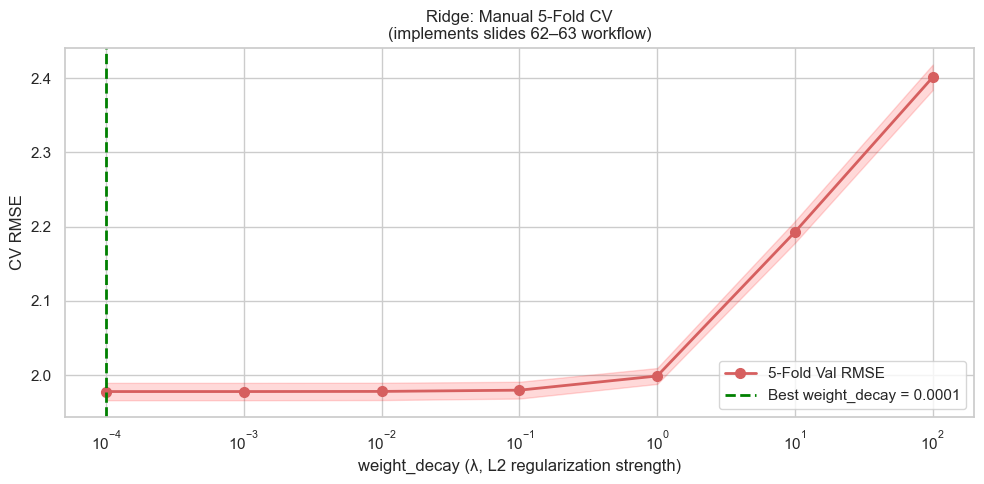

In [13]:
# ── K-Fold CV: Ridge — searching weight_decay (= λ) ──────────────────────────
wd_values = [1e-4, 1e-3, 1e-2, 0.1, 1.0, 10.0, 100.0]
kf      = KFold(n_splits=5, shuffle=True, random_state=42)
indices = np.arange(len(X_tr_t))

cv_ridge = {wd: [] for wd in wd_values}
for fold_tr, fold_val in kf.split(indices):
    X_f_tr  = X_tr_t[fold_tr];  y_f_tr  = y_tr_t[fold_tr]
    X_f_val = X_tr_t[fold_val]; y_f_val = y_tr_t[fold_val]
    for wd in wd_values:
        torch.manual_seed(0)
        m = LinearModel(n_features)
        opt_fold = optim.Adam(m.parameters(), lr=3e-3, weight_decay=wd)
        train_reg(m, X_f_tr, y_f_tr, opt_fold, n_epochs=100)
        with torch.no_grad():
            pred_val = m(X_f_val).numpy()
        cv_ridge[wd].append(np.sqrt(mean_squared_error(y_f_val.numpy(), pred_val)))

mean_cv  = {wd: np.mean(v) for wd, v in cv_ridge.items()}
std_cv   = {wd: np.std(v)  for wd, v in cv_ridge.items()}
best_wd_ridge = min(mean_cv, key=mean_cv.get)

print(f'Best weight_decay: {best_wd_ridge}')
print(f'Best CV RMSE: {mean_cv[best_wd_ridge]:.4f}')

# Train final model with best λ on full training set
torch.manual_seed(42)
model_ridge_best = LinearModel(n_features)
opt = optim.Adam(model_ridge_best.parameters(), lr=3e-3, weight_decay=best_wd_ridge)
train_reg(model_ridge_best, X_tr_t, y_tr_t, opt, n_epochs=500)
m_ridge_best = eval_reg(model_ridge_best, X_tr_t, y_tr_t, X_te_t, y_te_t,
                         f'Ridge (tuned wd={best_wd_ridge})')
print(f'Test R²:   {m_ridge_best["Test R²"]:.4f}')
print(f'Test RMSE: {np.sqrt(m_ridge_best["Test MSE"]):.4f}')

# Visualise CV curve
wds   = np.array(wd_values)
means = np.array([mean_cv[wd] for wd in wd_values])
stds  = np.array([std_cv[wd]  for wd in wd_values])

fig, ax = plt.subplots(figsize=(10, 5))
ax.semilogx(wds, means, 'r-o', label='5-Fold Val RMSE', lw=2, markersize=7)
ax.fill_between(wds, means - stds, means + stds, alpha=0.15, color='red')
ax.axvline(best_wd_ridge, color='green', ls='--', lw=2,
           label=f'Best weight_decay = {best_wd_ridge}')
ax.set_xlabel('weight_decay (λ, L2 regularization strength)', fontsize=12)
ax.set_ylabel('CV RMSE', fontsize=12)
ax.set_title('Ridge: Manual 5-Fold CV\n(implements slides 62–63 workflow)', fontsize=12)
ax.legend()
plt.tight_layout()
plt.show()

In [14]:
# ── K-Fold CV: Lasso — searching l1_lam ───────────────────────────────────────
l1_values = [1e-4, 1e-3, 1e-2, 0.1, 1.0]

cv_lasso = {lam: [] for lam in l1_values}
for fold_tr, fold_val in kf.split(indices):
    X_f_tr  = X_tr_t[fold_tr];  y_f_tr  = y_tr_t[fold_tr]
    X_f_val = X_tr_t[fold_val]; y_f_val = y_tr_t[fold_val]
    for lam in l1_values:
        torch.manual_seed(0)
        m = LinearModel(n_features)
        opt_fold = optim.Adam(m.parameters(), lr=3e-3)
        train_reg(m, X_f_tr, y_f_tr, opt_fold, n_epochs=100, l1_lam=lam)
        with torch.no_grad():
            pred_val = m(X_f_val).numpy()
        cv_lasso[lam].append(np.sqrt(mean_squared_error(y_f_val.numpy(), pred_val)))

best_l1_lam = min(l1_values, key=lambda lam: np.mean(cv_lasso[lam]))
print(f'Best Lasso λ: {best_l1_lam}')

# ── K-Fold CV: ElasticNet — grid over (l1_lam, weight_decay) ─────────────────
enet_grid = [(l1, wd) for l1 in [1e-3, 1e-2, 0.1] for wd in [1e-3, 1e-2, 0.1]]
cv_enet   = {params: [] for params in enet_grid}

for fold_tr, fold_val in kf.split(indices):
    X_f_tr  = X_tr_t[fold_tr];  y_f_tr  = y_tr_t[fold_tr]
    X_f_val = X_tr_t[fold_val]; y_f_val = y_tr_t[fold_val]
    for (l1, wd) in enet_grid:
        torch.manual_seed(0)
        m = LinearModel(n_features)
        opt_fold = optim.Adam(m.parameters(), lr=3e-3, weight_decay=wd)
        train_reg(m, X_f_tr, y_f_tr, opt_fold, n_epochs=100, l1_lam=l1)
        with torch.no_grad():
            pred_val = m(X_f_val).numpy()
        cv_enet[(l1, wd)].append(np.sqrt(mean_squared_error(y_f_val.numpy(), pred_val)))

best_enet_params = min(enet_grid, key=lambda p: np.mean(cv_enet[p]))
print(f'Best ElasticNet (l1_lam, weight_decay): {best_enet_params}')

# Train final tuned models
torch.manual_seed(42)
model_lasso_best = LinearModel(n_features)
opt = optim.Adam(model_lasso_best.parameters(), lr=3e-3)
train_reg(model_lasso_best, X_tr_t, y_tr_t, opt, n_epochs=500, l1_lam=best_l1_lam)
m_lasso_best = eval_reg(model_lasso_best, X_tr_t, y_tr_t, X_te_t, y_te_t,
                         f'Lasso (tuned λ={best_l1_lam})')

reg_results.append(m_ridge_best)
reg_results.append(m_lasso_best)
print(f'Tuned Ridge  Test R²: {m_ridge_best["Test R²"]:.4f}')
print(f'Tuned Lasso  Test R²: {m_lasso_best["Test R²"]:.4f}')

Best Lasso λ: 0.0001
Best ElasticNet (l1_lam, weight_decay): (0.001, 0.001)
Tuned Ridge  Test R²: 0.4583
Tuned Lasso  Test R²: 0.4583


=== Regression Results ===
                         Train R²  Test R²  Train MSE  Test MSE  Overfit Gap (R²)
Model                                                                            
LinearReg (no reg)         0.4784   0.4583     0.7078    0.7226            0.0202
Ridge (wd=1.0)             0.1702   0.1658     1.1262    1.1126            0.0043
Lasso (λ=0.01)             0.4759   0.4585     0.7112    0.7223            0.0175
ElasticNet (L1+L2)         0.4770   0.4585     0.7098    0.7222            0.0184
Ridge (tuned wd=0.0001)    0.4784   0.4583     0.7079    0.7226            0.0201
Lasso (tuned λ=0.0001)     0.4784   0.4583     0.7079    0.7225            0.0201


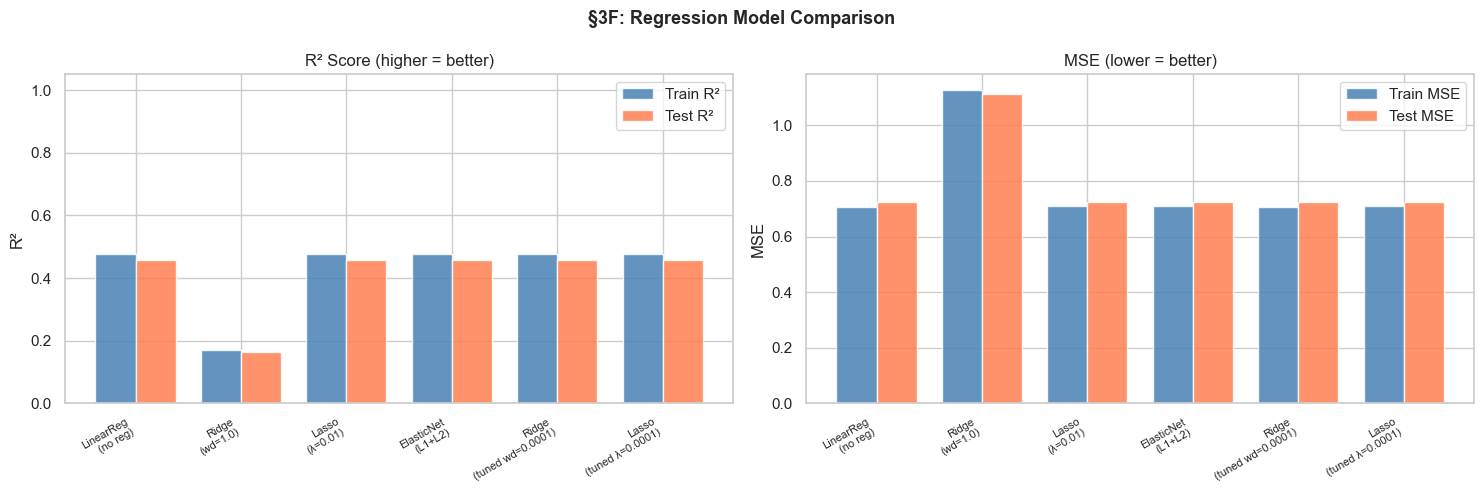


Small Train/Test gap → good generalisation (no severe overfitting)


In [15]:
# ── §3F  Regression Model Comparison ─────────────────────────────────────────
results_df = pd.DataFrame(reg_results).set_index('Model')
results_df['Overfit Gap (R²)'] = (results_df['Train R²'] - results_df['Test R²']).round(4)
print('=== Regression Results ===')
print(results_df[['Train R²','Test R²','Train MSE','Test MSE','Overfit Gap (R²)']]
      .round(4).to_string())

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
x   = np.arange(len(results_df))
w   = 0.38
lbls = [m.replace(' (', '\n(') for m in results_df.index]

axes[0].bar(x - w/2, results_df['Train R²'], w, label='Train R²', color='steelblue', alpha=0.85)
axes[0].bar(x + w/2, results_df['Test R²'],  w, label='Test R²',  color='coral',     alpha=0.85)
axes[0].set_xticks(x); axes[0].set_xticklabels(lbls, rotation=30, ha='right', fontsize=8)
axes[0].set_ylabel('R²'); axes[0].set_title('R² Score (higher = better)')
axes[0].legend(); axes[0].set_ylim(0, 1.05)

axes[1].bar(x - w/2, results_df['Train MSE'], w, label='Train MSE', color='steelblue', alpha=0.85)
axes[1].bar(x + w/2, results_df['Test MSE'],  w, label='Test MSE',  color='coral',     alpha=0.85)
axes[1].set_xticks(x); axes[1].set_xticklabels(lbls, rotation=30, ha='right', fontsize=8)
axes[1].set_ylabel('MSE'); axes[1].set_title('MSE (lower = better)')
axes[1].legend()

plt.suptitle('§3F: Regression Model Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print('\nSmall Train/Test gap → good generalisation (no severe overfitting)')


---
## §4  Binary Classification — Breast Cancer Dataset
> Predicting **Malignant (1)** vs **Benign (0)** from 30 numeric + 2 synthetic categorical features.
>
> **PyTorch Binary Classifier** = `nn.Linear(n, 1)` + **`BCEWithLogitsLoss`** (slide 28):
> - Forward pass outputs a raw **logit** `z = w·x + b` (no sigmoid applied)
> - `BCEWithLogitsLoss` fuses sigmoid + cross-entropy internally (numerically stable)
> - Prediction: `ŷ = 1` if `σ(z) ≥ threshold`, else `0`
>
> `BCEWithLogitsLoss = −[y · log σ(z) + (1−y) · log(1−σ(z))]`

In [16]:
bc     = load_breast_cancer(as_frame=True)
df_clf = bc.frame.copy()
# sklearn encodes 0=malignant, 1=benign; flip so 1=malignant (positive class)
df_clf['target'] = 1 - df_clf['target']

np.random.seed(42)
n_c = len(df_clf)
df_clf['patient_history'] = np.random.choice(
    ['none', 'mild', 'severe'], size=n_c, p=[0.50, 0.35, 0.15]
)
df_clf['biopsy_type'] = np.random.choice(
    ['FNA', 'core', 'excisional'], size=n_c, p=[0.45, 0.35, 0.20]
)

print(f'Shape: {df_clf.shape}')
vc = df_clf['target'].value_counts().rename({0:'Benign',1:'Malignant'})
print(f'\nClass distribution:\n{vc}')
print(f'Positive rate: {df_clf["target"].mean():.1%} malignant')


Shape: (569, 33)

Class distribution:
target
Benign       357
Malignant    212
Name: count, dtype: int64
Positive rate: 37.3% malignant


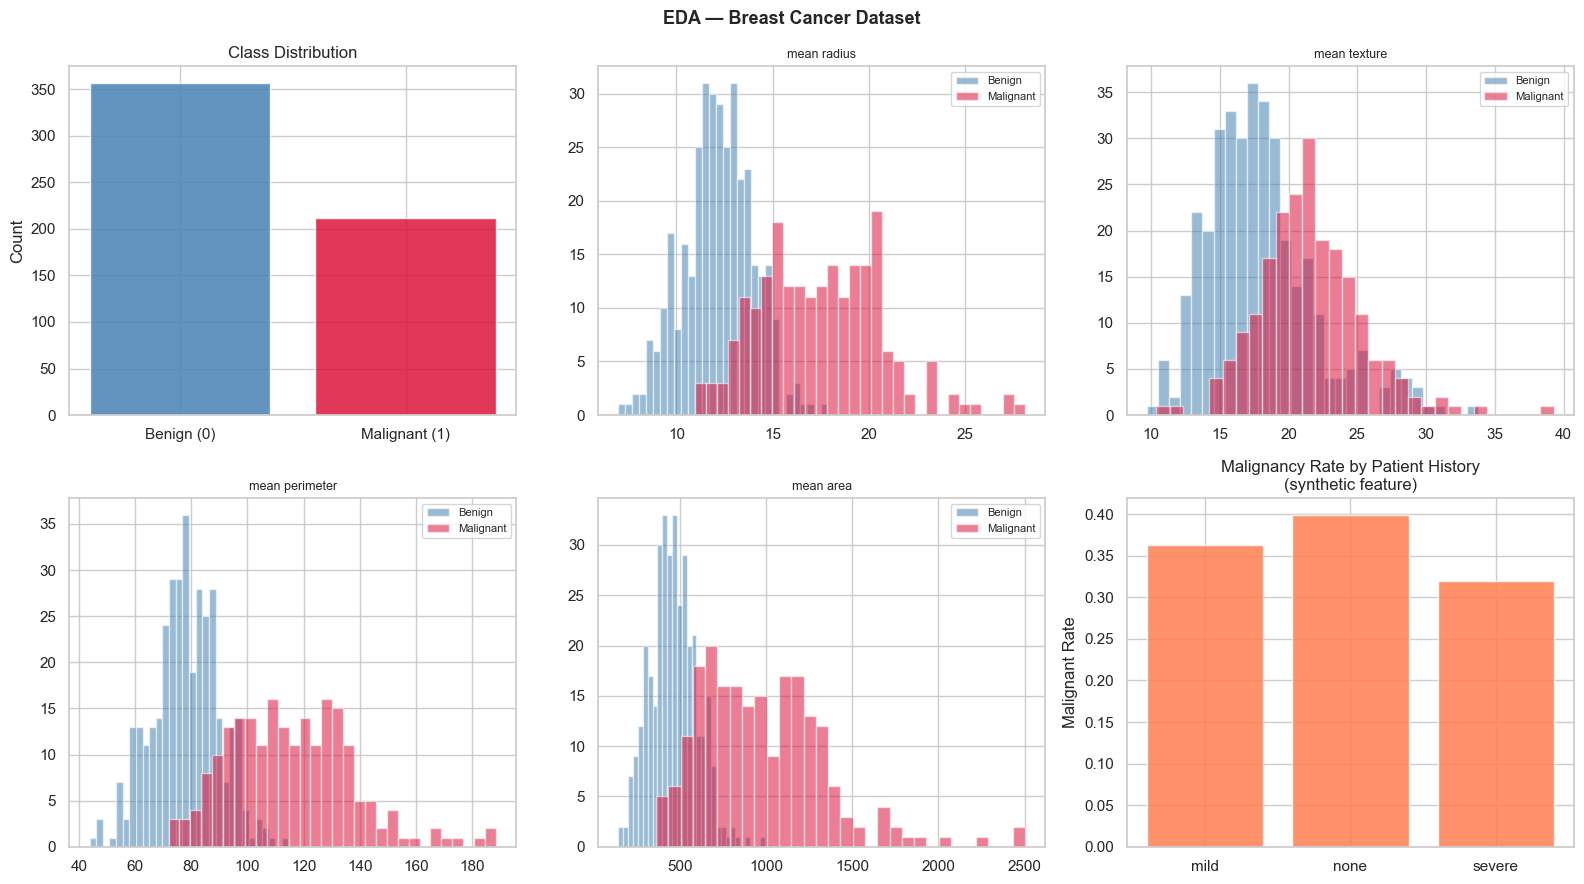

In [17]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

# Class counts
axes[0,0].bar(['Benign (0)','Malignant (1)'],
               df_clf['target'].value_counts().sort_index().values,
               color=['steelblue','crimson'], edgecolor='white', alpha=0.85)
axes[0,0].set_title('Class Distribution')
axes[0,0].set_ylabel('Count')

top4 = list(bc.feature_names[:4])
for i, feat in enumerate(top4):
    ax = axes[(i+1)//3, (i+1)%3]
    for cls, color, label in [(0,'steelblue','Benign'),(1,'crimson','Malignant')]:
        ax.hist(df_clf[df_clf['target']==cls][feat],
                bins=30, alpha=0.55, color=color, label=label, edgecolor='white')
    ax.set_title(feat, fontsize=9)
    ax.legend(fontsize=8)

ph = df_clf.groupby('patient_history')['target'].mean()
axes[1,2].bar(ph.index, ph.values, color='coral', edgecolor='white', alpha=0.85)
axes[1,2].set_title('Malignancy Rate by Patient History\n(synthetic feature)')
axes[1,2].set_ylabel('Malignant Rate')

plt.suptitle('EDA — Breast Cancer Dataset', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


In [ ]:
clf_num_feats = [str(f) for f in bc.feature_names]
clf_nom_feats = ['biopsy_type']
clf_ord_feats = ['patient_history']

X_clf = df_clf[clf_num_feats + clf_nom_feats + clf_ord_feats]
y_clf = df_clf['target']

X_tr_c, X_te_c, y_tr_c, y_te_c = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)
print(f'Train: {X_tr_c.shape}  |  Test: {X_te_c.shape}')
print(f'Train malignant: {y_tr_c.mean():.1%}  |  Test malignant: {y_te_c.mean():.1%}')

preprocessor_c = ColumnTransformer(transformers=[
    ('num', StandardScaler(),                                              clf_num_feats),
    ('nom', OneHotEncoder(drop='first', handle_unknown='ignore'),          clf_nom_feats),
    ('ord', OrdinalEncoder(categories=[['none', 'mild', 'severe']]),       clf_ord_feats),
], remainder='drop')

# Fit on train, transform both splits → PyTorch tensors
X_tr_c_np = preprocessor_c.fit_transform(X_tr_c)
X_te_c_np = preprocessor_c.transform(X_te_c)

X_tr_c_t = torch.tensor(X_tr_c_np, dtype=torch.float32)
X_te_c_t = torch.tensor(X_te_c_np, dtype=torch.float32)
y_tr_c_t = torch.tensor(y_tr_c.values, dtype=torch.float32)  # float for BCEWithLogitsLoss
y_te_np  = y_te_c.values
n_clf_features = X_tr_c_t.shape[1]

print(f'\nTensor shapes — X_tr: {tuple(X_tr_c_t.shape)}, y_tr: {tuple(y_tr_c_t.shape)}')

# ── Binary Classifier Model + Utilities ───────────────────────────────────────

class BinaryClassifier(nn.Module):
    """nn.Linear → logit. BCEWithLogitsLoss handles sigmoid internally."""
    def __init__(self, n_in):
        super().__init__()
        self.linear = nn.Linear(n_in, 1)

    def forward(self, x):
        return self.linear(x).squeeze(-1) # apply sigmoid in loss function, not here

def inverse (x):
    """Inverse sigmoid (logit) function."""
    return 1./(1+ 1e-6)
def train_clf(model, X, y, optimizer, n_epochs=500, l1_lam=0.0):
    """Full-batch training for binary classification. Returns BCE loss history."""
    criterion = nn.BCEWithLogitsLoss() # nn.BCELoss expects probabilities, but BCEWithLogitsLoss expects raw logits
    model.train()
    losses = []
    for _ in range(n_epochs):
        optimizer.zero_grad()
        loss = criterion(model(X), y)
        if l1_lam > 0:
            l1 = sum(p.abs().sum() for p in model.parameters())
            loss = loss + l1_lam * l1
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
    return losses


@torch.no_grad()
def predict_proba_clf(model, X):
    model.eval()
    return torch.sigmoid(model(X)).numpy()


@torch.no_grad()
def predict_clf(model, X, threshold=0.5):
    return (predict_proba_clf(model, X) >= threshold).astype(int)

print('✓ BinaryClassifier, train_clf(), predict_proba_clf(), predict_clf() defined')

Train: (455, 32)  |  Test: (114, 32)
Train malignant: 37.4%  |  Test malignant: 36.8%

Tensor shapes — X_tr: (455, 33), y_tr: (455,)
✓ BinaryClassifier, train_clf(), predict_proba_clf(), predict_clf() defined


In [19]:
# ── §4A  Logistic Regression — No Regularization ──────────────────────────────
# nn.Linear(n, 1) → logit z → BCEWithLogitsLoss applies sigmoid internally

torch.manual_seed(42)
model_clf_base = BinaryClassifier(n_clf_features)
opt_base = optim.Adam(model_clf_base.parameters(), lr=3e-3)
train_clf(model_clf_base, X_tr_c_t, y_tr_c_t, opt_base, n_epochs=500)

y_pred_base = predict_clf(model_clf_base, X_te_c_t)
y_prob_base = predict_proba_clf(model_clf_base, X_te_c_t)

print('§4A  Logistic Regression (no regularization)')
print(f'  Accuracy:  {accuracy_score(y_te_np,  y_pred_base):.4f}')
print(f'  Precision: {precision_score(y_te_np, y_pred_base):.4f}')
print(f'  Recall:    {recall_score(y_te_np,    y_pred_base):.4f}')
print(f'  F1:        {f1_score(y_te_np,        y_pred_base):.4f}')
print(f'  AUC-ROC:   {roc_auc_score(y_te_np,   y_prob_base):.4f}')

§4A  Logistic Regression (no regularization)
  Accuracy:  0.9825
  Precision: 1.0000
  Recall:    0.9524
  F1:        0.9756
  AUC-ROC:   0.9977


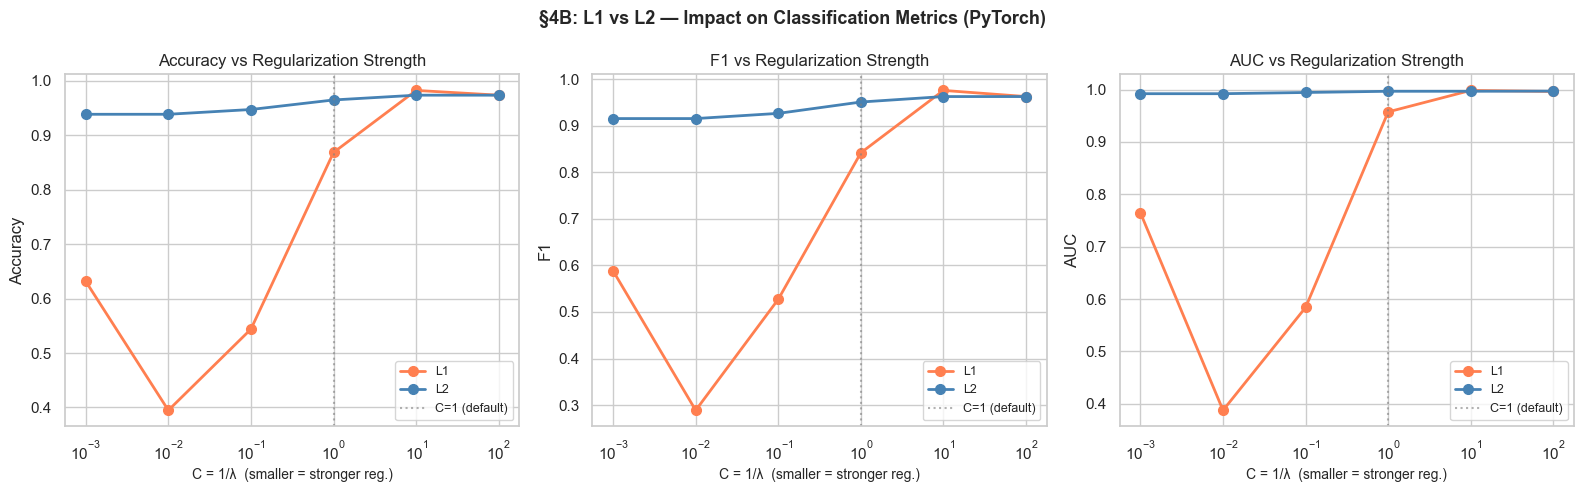

In [20]:
# ── §4B  L1 vs L2 — impact of C = 1/λ on classification metrics ───────────────
# PyTorch: weight_decay for L2, manual l1_lam for L1

C_values = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]
clf_sweep = []

for C in C_values:
    lam = 1.0 / C  # sklearn convention: C = 1/λ

    # L2 via weight_decay
    torch.manual_seed(0)
    m_l2 = BinaryClassifier(n_clf_features)
    opt = optim.Adam(m_l2.parameters(), lr=3e-3, weight_decay=lam)
    train_clf(m_l2, X_tr_c_t, y_tr_c_t, opt, n_epochs=200)
    yp  = predict_clf(m_l2, X_te_c_t)
    ypr = predict_proba_clf(m_l2, X_te_c_t)
    clf_sweep.append({'C': C, 'Penalty': 'L2',
                      'Accuracy': accuracy_score(y_te_np, yp),
                      'F1':       f1_score(y_te_np, yp),
                      'AUC':      roc_auc_score(y_te_np, ypr)})

    # L1 via manual penalty
    torch.manual_seed(0)
    m_l1 = BinaryClassifier(n_clf_features)
    opt = optim.Adam(m_l1.parameters(), lr=3e-3)
    train_clf(m_l1, X_tr_c_t, y_tr_c_t, opt, n_epochs=200, l1_lam=lam)
    yp  = predict_clf(m_l1, X_te_c_t)
    ypr = predict_proba_clf(m_l1, X_te_c_t)
    clf_sweep.append({'C': C, 'Penalty': 'L1',
                      'Accuracy': accuracy_score(y_te_np, yp),
                      'F1':       f1_score(y_te_np, yp),
                      'AUC':      roc_auc_score(y_te_np, ypr)})

sweep_df = pd.DataFrame(clf_sweep)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for metric, ax in zip(['Accuracy', 'F1', 'AUC'], axes):
    for penalty, color in [('L1','coral'), ('L2','steelblue')]:
        sub = sweep_df[sweep_df['Penalty'] == penalty]
        ax.semilogx(sub['C'], sub[metric], 'o-', color=color,
                    label=penalty, lw=2, markersize=7)
    ax.axvline(1.0, color='gray', ls=':', alpha=0.6, label='C=1 (default)')
    ax.set_xlabel('C = 1/λ  (smaller = stronger reg.)', fontsize=10)
    ax.set_ylabel(metric)
    ax.set_title(f'{metric} vs Regularization Strength')
    ax.legend(fontsize=9)

plt.suptitle('§4B: L1 vs L2 — Impact on Classification Metrics (PyTorch)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Best weight_decay (L2): 0.1
Best CV AUC: 0.9913
Test AUC: 0.9977
Test F1:  0.9630


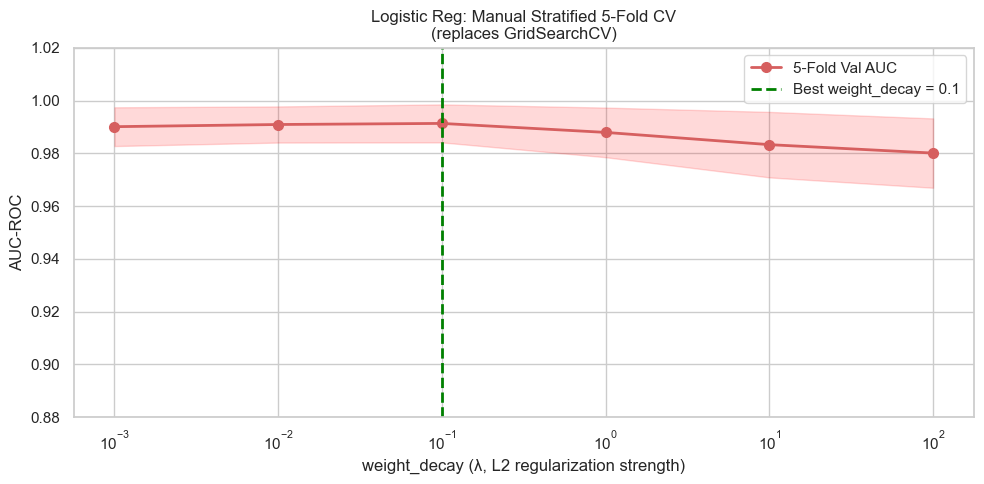

In [21]:
# ── §4C  Manual StratifiedKFold CV — Logistic Regression (L2) ─────────────────
wd_clf_values = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]  # λ = weight_decay
skf       = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
indices_c = np.arange(len(X_tr_c_t))
y_tr_c_arr = y_tr_c.values

cv_auc_clf = {wd: [] for wd in wd_clf_values}
for fold_tr, fold_val in skf.split(indices_c, y_tr_c_arr):
    X_f_tr  = X_tr_c_t[fold_tr]; y_f_tr  = y_tr_c_t[fold_tr]
    X_f_val = X_tr_c_t[fold_val]
    y_f_arr = y_tr_c_arr[fold_val]
    for wd in wd_clf_values:
        torch.manual_seed(0)
        m = BinaryClassifier(n_clf_features)
        opt_fold = optim.Adam(m.parameters(), lr=3e-3, weight_decay=wd)
        train_clf(m, X_f_tr, y_f_tr, opt_fold, n_epochs=100)
        ypr_val = predict_proba_clf(m, X_f_val)
        cv_auc_clf[wd].append(roc_auc_score(y_f_arr, ypr_val))

mean_auc = {wd: np.mean(v) for wd, v in cv_auc_clf.items()}
std_auc  = {wd: np.std(v)  for wd, v in cv_auc_clf.items()}
best_wd_clf = max(mean_auc, key=mean_auc.get)

print(f'Best weight_decay (L2): {best_wd_clf}')
print(f'Best CV AUC: {mean_auc[best_wd_clf]:.4f}')

# Train final model on full training set
torch.manual_seed(42)
model_clf_best = BinaryClassifier(n_clf_features)
opt = optim.Adam(model_clf_best.parameters(), lr=3e-3, weight_decay=best_wd_clf)
train_clf(model_clf_best, X_tr_c_t, y_tr_c_t, opt, n_epochs=500)

y_pred_tuned = predict_clf(model_clf_best, X_te_c_t)
y_prob_tuned = predict_proba_clf(model_clf_best, X_te_c_t)
print(f'Test AUC: {roc_auc_score(y_te_np, y_prob_tuned):.4f}')
print(f'Test F1:  {f1_score(y_te_np, y_pred_tuned):.4f}')

# CV curve
wds_arr   = np.array(wd_clf_values)
means_arr = np.array([mean_auc[wd] for wd in wd_clf_values])
stds_arr  = np.array([std_auc[wd]  for wd in wd_clf_values])

fig, ax = plt.subplots(figsize=(10, 5))
ax.semilogx(wds_arr, means_arr, 'r-o', label='5-Fold Val AUC', lw=2, markersize=7)
ax.fill_between(wds_arr, means_arr - stds_arr, means_arr + stds_arr, alpha=0.15, color='red')
ax.axvline(best_wd_clf, color='green', ls='--', lw=2,
           label=f'Best weight_decay = {best_wd_clf}')
ax.set_xlabel('weight_decay (λ, L2 regularization strength)', fontsize=12)
ax.set_ylabel('AUC-ROC', fontsize=12)
ax.set_title('Logistic Reg: Manual Stratified 5-Fold CV\n(replaces GridSearchCV)', fontsize=12)
ax.legend()
ax.set_ylim(0.88, 1.02)
plt.tight_layout()
plt.show()

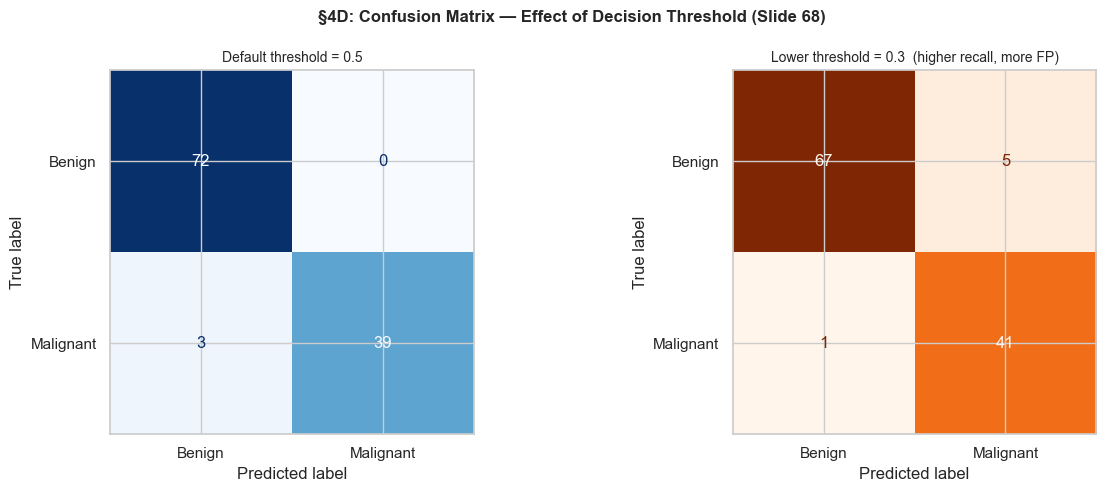

          Accuracy Precision  Recall      F1     FPR     FNR
Threshold                                                   
0.5         0.9737    1.0000  0.9286  0.9630  0.0000  0.0714
0.3         0.9474    0.8913  0.9762  0.9318  0.0694  0.0238


In [22]:
# ── §4D  Confusion Matrix (Slides 66–68) ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, thresh, cmap, title_suffix in [
    (axes[0], 0.5, 'Blues',   'Default threshold = 0.5'),
    (axes[1], 0.3, 'Oranges', 'Lower threshold = 0.3  (higher recall, more FP)'),
]:
    yp = (y_prob_tuned >= thresh).astype(int)
    cm = confusion_matrix(y_te_c, yp)
    ConfusionMatrixDisplay(cm, display_labels=['Benign', 'Malignant']).plot(
        ax=ax, colorbar=False, cmap=cmap
    )
    ax.set_title(title_suffix, fontsize=10)

plt.suptitle('§4D: Confusion Matrix — Effect of Decision Threshold (Slide 68)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

rows = []
for thresh in [0.5, 0.3]:
    yp = (y_prob_tuned >= thresh).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_te_c, yp).ravel()
    rows.append({
        'Threshold': thresh,
        'Accuracy':  f'{accuracy_score(y_te_c, yp):.4f}',
        'Precision': f'{precision_score(y_te_c, yp):.4f}',
        'Recall':    f'{recall_score(y_te_c, yp):.4f}',
        'F1':        f'{f1_score(y_te_c, yp):.4f}',
        'FPR':       f'{fp/(fp+tn):.4f}',
        'FNR':       f'{fn/(fn+tp):.4f}',
    })
print(pd.DataFrame(rows).set_index('Threshold').to_string())


In [23]:
# ── §4E  Full Classification Report (Slide 67) ───────────────────────────────
print(f'Classification Report — Best Logistic Regression (L2, weight_decay={best_wd_clf})')
print('=' * 60)
print(classification_report(y_te_c, y_pred_tuned,
                             target_names=['Benign', 'Malignant']))

Classification Report — Best Logistic Regression (L2, weight_decay=0.1)
              precision    recall  f1-score   support

      Benign       0.96      1.00      0.98        72
   Malignant       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114



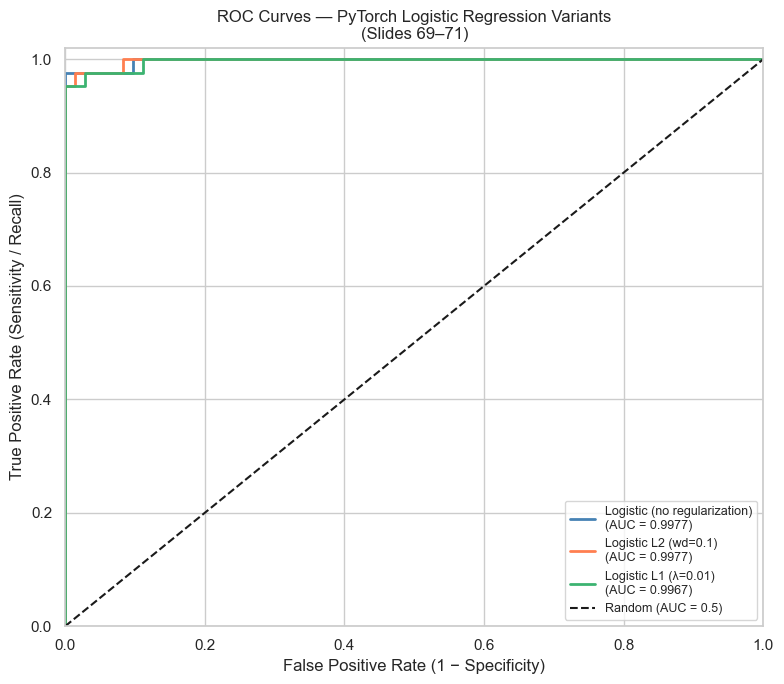

AUC Interpretation:
  1.0 = Perfect  |  0.9–1.0 = Excellent  |  0.8–0.9 = Good
  0.7–0.8 = Fair  |  0.5 = Random classifier (no skill)


In [24]:
# ── §4F  ROC Curves + AUC (Slides 69–71) ─────────────────────────────────────
# Tune L1 logistic model via the same StratifiedKFold setup

l1_values_clf = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]
cv_auc_l1 = {lam: [] for lam in l1_values_clf}

for fold_tr, fold_val in skf.split(indices_c, y_tr_c_arr):
    X_f_tr  = X_tr_c_t[fold_tr]; y_f_tr  = y_tr_c_t[fold_tr]
    X_f_val = X_tr_c_t[fold_val]; y_f_arr = y_tr_c_arr[fold_val]
    for lam in l1_values_clf:
        torch.manual_seed(0)
        m = BinaryClassifier(n_clf_features)
        opt_fold = optim.Adam(m.parameters(), lr=3e-3)
        train_clf(m, X_f_tr, y_f_tr, opt_fold, n_epochs=100, l1_lam=lam)
        cv_auc_l1[lam].append(roc_auc_score(y_f_arr, predict_proba_clf(m, X_f_val)))

best_l1_clf = max(l1_values_clf, key=lambda lam: np.mean(cv_auc_l1[lam]))

torch.manual_seed(42)
model_clf_l1 = BinaryClassifier(n_clf_features)
opt = optim.Adam(model_clf_l1.parameters(), lr=3e-3)
train_clf(model_clf_l1, X_tr_c_t, y_tr_c_t, opt, n_epochs=500, l1_lam=best_l1_clf)
y_prob_l1 = predict_proba_clf(model_clf_l1, X_te_c_t)

models_roc = {
    'Logistic (no regularization)':           y_prob_base,
    f'Logistic L2 (wd={best_wd_clf})':        y_prob_tuned,
    f'Logistic L1 (λ={best_l1_clf})':         y_prob_l1,
}

fig, ax = plt.subplots(figsize=(8, 7))
colors_roc = ['steelblue', 'coral', 'mediumseagreen']

for (name, y_prob), color in zip(models_roc.items(), colors_roc):
    fpr, tpr, _ = roc_curve(y_te_np, y_prob)
    auc_val = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, lw=2, label=f'{name}\n(AUC = {auc_val:.4f})')

ax.plot([0,1],[0,1], 'k--', lw=1.5, label='Random (AUC = 0.5)')
ax.set_xlabel('False Positive Rate (1 − Specificity)', fontsize=12)
ax.set_ylabel('True Positive Rate (Sensitivity / Recall)', fontsize=12)
ax.set_title('ROC Curves — PyTorch Logistic Regression Variants\n(Slides 69–71)', fontsize=12)
ax.legend(loc='lower right', fontsize=9)
ax.set_xlim([0,1]); ax.set_ylim([0,1.02])
plt.tight_layout()
plt.show()

print('AUC Interpretation:')
print('  1.0 = Perfect  |  0.9–1.0 = Excellent  |  0.8–0.9 = Good')
print('  0.7–0.8 = Fair  |  0.5 = Random classifier (no skill)')

---
## §5  Multiclass Classification — Softmax / CrossEntropyLoss
> **Slides 29–31** — For K classes the output activation is **softmax**:
>
> `p(class k | x) = exp(zₖ) / Σⱼ exp(zⱼ)` where `z = WXᵀ + w₀`
>
> **PyTorch implementation:**
> - Model: `nn.Linear(n_features, n_classes)` → K logits (no softmax in `forward`)
> - Loss: `nn.CrossEntropyLoss()` applies log-softmax internally (numerically stable)
> - Labels: `torch.long` integer class indices (not one-hot)
>
> Each class gets its own weight vector → decision boundaries are **linear**.

In [ ]:
iris = load_iris(as_frame=True)
X_iris = iris.data
y_iris = iris.target

X_tr_i, X_te_i, y_tr_i, y_te_i = train_test_split(
    X_iris, y_iris, test_size=0.2, random_state=42, stratify=y_iris
)

sc_iris   = StandardScaler()
X_tr_i_np = sc_iris.fit_transform(X_tr_i)
X_te_i_np = sc_iris.transform(X_te_i)

X_tr_i_t  = torch.tensor(X_tr_i_np, dtype=torch.float32)
X_te_i_t  = torch.tensor(X_te_i_np, dtype=torch.float32)
y_tr_i_t  = torch.tensor(y_tr_i.values, dtype=torch.long)   # CrossEntropyLoss needs LongTensor
y_te_i_arr = y_te_i.values

# ── Softmax Classifier (nn.Linear → K logits) ─────────────────────────────────

class SoftmaxClassifier(nn.Module):
    """nn.Linear → K logits. CrossEntropyLoss applies log-softmax internally."""
    def __init__(self, n_in, n_classes):
        super().__init__()
        self.linear = nn.Linear(n_in, n_classes)

    def forward(self, x):
        return self.linear(x)


@torch.no_grad()
def predict_multiclass(model, X):
    model.eval()
    return model(X).argmax(dim=1).numpy() # [-1,2,0,4,5] -> [0.1,0.3,0,0.1,0.5] -> argmax -> [2,3,1,4,5]


# ── K-Fold CV to find best weight_decay ───────────────────────────────────────
wd_mc_values = [0.01, 0.1, 1.0, 10.0, 100.0]
skf_mc = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
criterion_mc = nn.CrossEntropyLoss()

cv_acc_mc = {wd: [] for wd in wd_mc_values}
for fold_tr, fold_val in skf_mc.split(np.arange(len(X_tr_i_t)), y_tr_i.values):
    X_f_tr = X_tr_i_t[fold_tr]; y_f_tr = y_tr_i_t[fold_tr]
    X_f_val = X_tr_i_t[fold_val]; y_f_arr = y_tr_i.values[fold_val]
    for wd in wd_mc_values:
        torch.manual_seed(0)
        m = SoftmaxClassifier(4, 3)
        opt_fold = optim.Adam(m.parameters(), lr=3e-3, weight_decay=wd)
        m.train()
        for _ in range(200):
            opt_fold.zero_grad()
            criterion_mc(m(X_f_tr), y_f_tr).backward()
            opt_fold.step()
        cv_acc_mc[wd].append(accuracy_score(y_f_arr, predict_multiclass(m, X_f_val)))

best_wd_mc = max(wd_mc_values, key=lambda wd: np.mean(cv_acc_mc[wd]))
print(f'Best weight_decay: {best_wd_mc}')

# Train final model
torch.manual_seed(42)
model_mc = SoftmaxClassifier(4, 3)
opt_mc   = optim.Adam(model_mc.parameters(), lr=3e-3, weight_decay=best_wd_mc)
model_mc.train()
for _ in range(500):
    opt_mc.zero_grad()
    criterion_mc(model_mc(X_tr_i_t), y_tr_i_t).backward()
    opt_mc.step()

y_pred_iris = predict_multiclass(model_mc, X_te_i_t)
print(f'Test Accuracy: {accuracy_score(y_te_i_arr, y_pred_iris):.4f}')
print()
print(classification_report(y_te_i_arr, y_pred_iris, target_names=iris.target_names))

Best weight_decay: 0.1
Test Accuracy: 0.8333

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.86      0.60      0.71        10
   virginica       0.69      0.90      0.78        10

    accuracy                           0.83        30
   macro avg       0.85      0.83      0.83        30
weighted avg       0.85      0.83      0.83        30



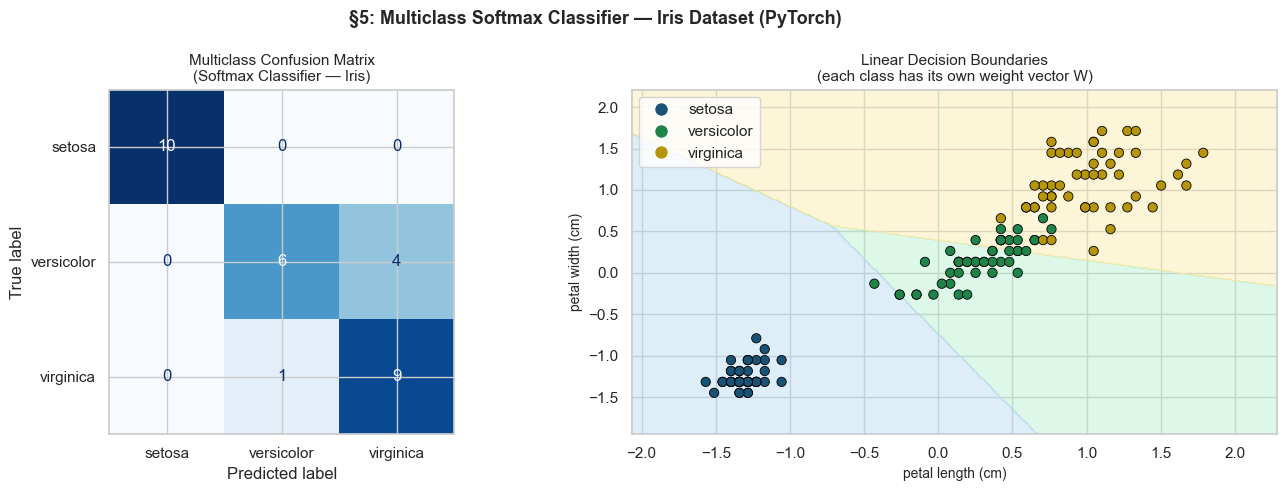

In [26]:
from matplotlib.colors import ListedColormap

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix
cm_iris = confusion_matrix(y_te_i_arr, y_pred_iris)
ConfusionMatrixDisplay(cm_iris, display_labels=iris.target_names).plot(
    ax=axes[0], cmap='Blues', colorbar=False
)
axes[0].set_title('Multiclass Confusion Matrix\n(Softmax Classifier — Iris)', fontsize=11)

# Linear decision boundaries on 2 features
feat_idx   = [2, 3]
feat_names = [iris.feature_names[i] for i in feat_idx]
X_2d       = X_iris.iloc[:, feat_idx].values
y_2d       = y_iris.values

sc_2d    = StandardScaler()
X_2d_sc  = sc_2d.fit_transform(X_2d)
X_2d_t   = torch.tensor(X_2d_sc, dtype=torch.float32)
y_2d_t   = torch.tensor(y_2d,    dtype=torch.long)

torch.manual_seed(42)
model_2d = SoftmaxClassifier(2, 3)
opt_2d   = optim.Adam(model_2d.parameters(), lr=3e-3, weight_decay=best_wd_mc)
crit_2d  = nn.CrossEntropyLoss()
model_2d.train()
for _ in range(500):
    opt_2d.zero_grad()
    crit_2d(model_2d(X_2d_t), y_2d_t).backward()
    opt_2d.step()

x0_min, x0_max = X_2d_sc[:,0].min()-0.5, X_2d_sc[:,0].max()+0.5
x1_min, x1_max = X_2d_sc[:,1].min()-0.5, X_2d_sc[:,1].max()+0.5
xx, yy = np.meshgrid(np.linspace(x0_min,x0_max,300),
                      np.linspace(x1_min,x1_max,300))
grid_t = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32)
Z = predict_multiclass(model_2d, grid_t).reshape(xx.shape)

cmap_bg  = ListedColormap(['#AED6F1','#ABEBC6','#F9E79F'])
cmap_pts = ListedColormap(['#1A5276','#1E8449','#B7950B'])
axes[1].contourf(xx, yy, Z, alpha=0.40, cmap=cmap_bg)
axes[1].scatter(X_2d_sc[:,0], X_2d_sc[:,1], c=y_2d, cmap=cmap_pts,
                edgecolors='black', s=45, linewidths=0.6)
axes[1].set_xlabel(feat_names[0], fontsize=10)
axes[1].set_ylabel(feat_names[1], fontsize=10)
axes[1].set_title('Linear Decision Boundaries\n(each class has its own weight vector W)',
                   fontsize=11)
handles = [
    plt.Line2D([0],[0], marker='o', color='w',
                markerfacecolor=c, markersize=10, label=n)
    for c, n in zip(['#1A5276','#1E8449','#B7950B'], iris.target_names)
]
axes[1].legend(handles=handles)

plt.suptitle('§5: Multiclass Softmax Classifier — Iris Dataset (PyTorch)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Summary

### Key Takeaways from Module 1 — PyTorch Edition

| Concept | sklearn approach | PyTorch approach |
|---------|-----------------|------------------|
| **Linear equation** `Y = WXᵀ + w₀` | `LinearRegression` | `nn.Linear(n, 1)` |
| **Activation functions** | Built-in | `torch.sigmoid`, `torch.relu`, `torch.tanh` |
| **Input encoding / scaling** | `ColumnTransformer` | sklearn → `.fit_transform()` → `torch.tensor()` |
| **Linear Regression** | `LinearRegression()` | `nn.Linear` + `MSELoss` |
| **Ridge (L2)** | `Ridge(alpha=λ)` | `optim.Adam(..., weight_decay=λ)` |
| **Lasso (L1)** | `Lasso(alpha=λ)` | Manual `loss += λ · Σ\|w\|` |
| **ElasticNet** | `ElasticNet(alpha, l1_ratio)` | `weight_decay` (L2) + manual L1 penalty |
| **Hyperparameter tuning** | `GridSearchCV` | Manual K-Fold loop |
| **Regression metrics** | `r2_score`, `mean_squared_error` | sklearn (unchanged) |
| **Logistic Regression** | `LogisticRegression` | `nn.Linear(n,1)` + `BCEWithLogitsLoss` |
| **Confusion matrix / Report** | `ConfusionMatrixDisplay` | sklearn (unchanged) |
| **ROC curve + AUC** | `roc_curve`, `auc` | sklearn (unchanged) |
| **Softmax / Multinomial** | `LogisticRegression(multi_class='multinomial')` | `nn.Linear(n, K)` + `CrossEntropyLoss` |

### Connection to Deep Learning

```
Linear Regression    =  nn.Linear(n, 1)  +  MSELoss
Logistic Regression  =  nn.Linear(n, 1)  +  BCEWithLogitsLoss   ← sigmoid inside loss
Softmax Classifier   =  nn.Linear(n, K)  +  CrossEntropyLoss    ← softmax inside loss
Neural Network       =  nn.Sequential(Linear, ReLU, Linear, ...)  +  any loss
Deep Neural Network  =  many nn.Linear layers + non-linear activations (ReLU, tanh …)
```

> "A linear activation function produces linear decisions **no matter the network size**.  
> Non-linearities allow us to approximate arbitrarily complex functions." — Slide 19